In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../Data/ai_job_dataset.csv")
# Initial overview
print(f"Dataset Shape: {df.shape}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

# 국가, 직군, 연차

Dataset Shape: (15000, 19)

Memory Usage: 2.17 MB

First few rows:


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [8]:
df.required_skills.unique()

array(['Tableau, PyTorch, Kubernetes, Linux, NLP',
       'Deep Learning, AWS, Mathematics, Python, Docker',
       'Kubernetes, Deep Learning, Java, Hadoop, NLP', ...,
       'Scala, Spark, NLP', 'Java, Computer Vision, Python, TensorFlow',
       'Scala, Azure, Deep Learning, GCP, Mathematics'], dtype=object)

In [3]:
# 1. salary_usd 기반 라벨링 (low, mid, high)
# 연봉 구간에 따른 라벨 추가
def label_salary(salary):
    if salary <= 70000:
        return 'low'
    elif salary <= 140000:
        return 'mid'
    else:
        return 'high'

df['salary_label'] = df['salary_usd'].apply(label_salary)

In [4]:
# 2. 필요한 feature 추출

df_subset = df[['company_location', 'years_experience', 'salary_label',
                'benefits_score', 'industry', 'company_size', 'salary_usd']].dropna()

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ['company_location', 'industry', 'company_size']
num_cols = ['years_experience', 'benefits_score']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 전처리 (분류기 없이 전처리만 사용)
X_processed = preprocessor.fit_transform(X)

# 2. PCA (2차원으로 축소)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

# 3. KMeans (군집 수는 3으로 지정)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# 4. 시각화
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set2', alpha=0.6)
plt.title("📊 PCA + KMeans 군집 시각화")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

NameError: name 'X' is not defined

In [ ]:
X_processed = preprocessor.fit_transform(df_subset.drop('salary_label', axis=1))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# y는 기존 label
y = df_subset['salary_label']

# 전처리된 X로 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, stratify=y, test_size=0.2, random_state=42
)

# 랜덤포레스트 분류기
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 예측
y_pred = clf.predict(X_test)

# 평가
print("✅ 정확도:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

✅ 정확도: 0.829

📊 Classification Report:
               precision    recall  f1-score   support

        high       0.84      0.83      0.84       824
         low       0.85      0.81      0.83       744
         mid       0.81      0.84      0.82      1432

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000

🧩 Confusion Matrix:
 [[ 683    0  141]
 [   0  606  138]
 [ 127  107 1198]]


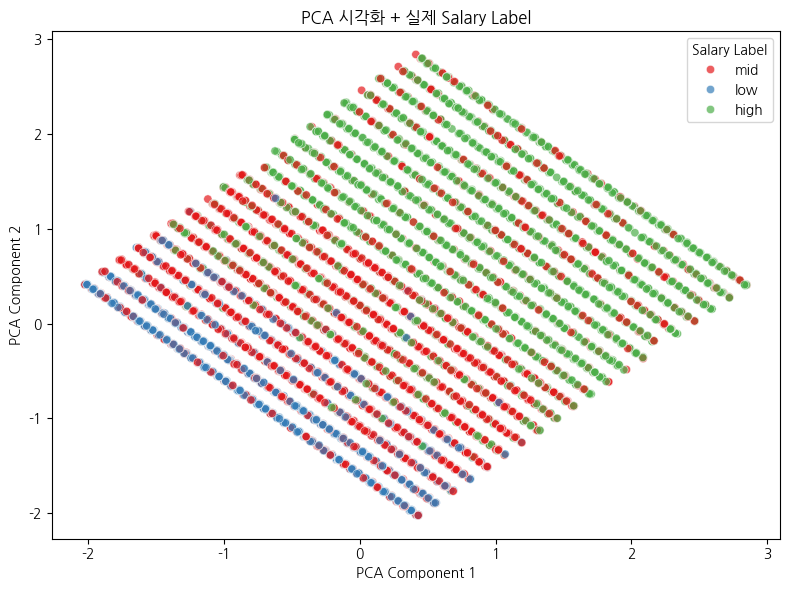

In [ ]:
import seaborn as sns

# 1. PCA 결과와 라벨 결합
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["salary_label"] = y.values

# 2. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="salary_label", palette="Set1", alpha=0.7)
plt.title("PCA 시각화 + 실제 Salary Label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Salary Label")
plt.tight_layout()
plt.show()

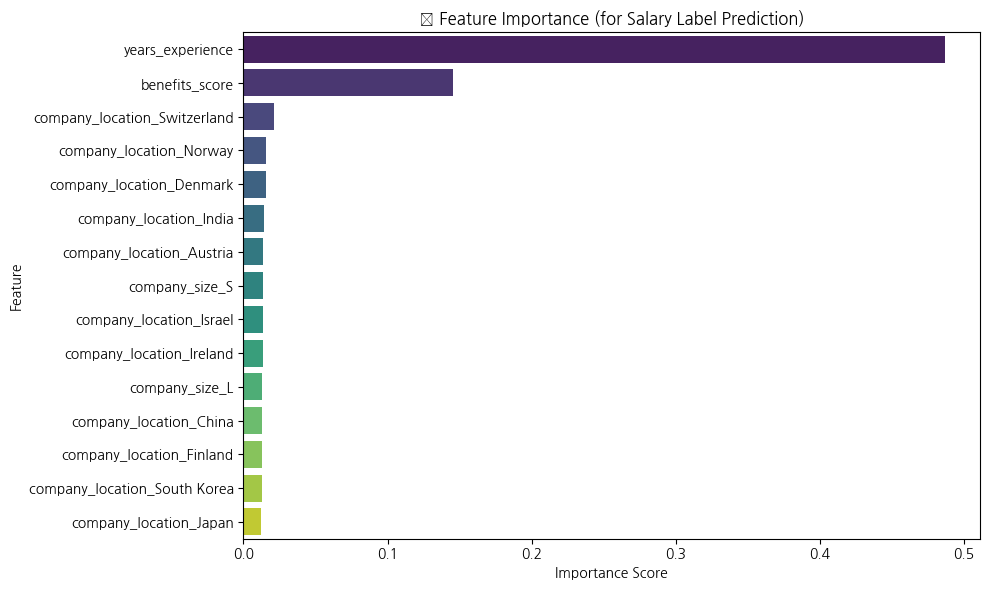

In [ ]:
# 랜덤포레스트 feature importance
importances = clf.feature_importances_

# 원핫/스케일링된 feature 이름 추출
encoded_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(encoded_cat) + num_cols

# 중요도 시각화
importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(15)  # 상위 15개만 보기

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title("🌳 Feature Importance (for Salary Label Prediction)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# 데이터 분리
X = df_subset.drop('salary_label', axis=1)
y = df_subset['salary_label']

# 열 타입 구분
cat_cols = ['company_location', 'industry', 'company_size']
num_cols = ['years_experience', 'benefits_score']

# 전처리 파이프라인
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# 전체 파이프라인 정의
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 학습/검증 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# 모델 학습
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['company_location',
                                                   'industry',
                                                   'company_size']),
                                                 ('num', StandardScaler(),
                                                  ['years_experience',
                                                   'benefits_score'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
# 사용자 입력
new_user = pd.DataFrame([{
    'company_location': 'South Korea',
    'years_experience': 3,
    'benefits_score': 1.2,
    'industry': 'Technology',
    'company_size': 'L'
}])

# 🎯 1. 새 유저 예측
predicted_label = pipeline.predict(new_user)[0]
print(f"🧭 새 사용자는 '{predicted_label.upper()}' 연봉 그룹에 속합니다.\n")

# 🎯 2. 예측된 salary_label 기준으로 통계 계산
df_labeled = df_subset.copy()
df_labeled['predicted_label'] = pipeline.predict(X)

# 💰 연봉 통계
salary_stats_by_label = df.groupby('salary_label')['salary_usd'].agg(['mean', 'min', 'max']).round(0)
stats = salary_stats_by_label.loc[predicted_label]

print("💰 이 연봉 그룹의 연봉 통계:")
print(f"• 평균 연봉: ${int(stats['mean']):,}")
print(f"• 범위: ${int(stats['min']):,} ~ ${int(stats['max']):,}\n")

# 특성 경향
feature_trends = df_subset.groupby('salary_label')[['years_experience', 'benefits_score']].mean().round(1)
top_industries = df_subset.groupby('salary_label')['industry'].agg(lambda x: x.value_counts().index[0])
top_sizes = df_subset.groupby('salary_label')['company_size'].agg(lambda x: x.value_counts().index[0])

print("주요 특성:")
print(f"• 평균 연차: {feature_trends.loc[predicted_label]['years_experience']}년")
print(f"• 평균 복지 점수: {feature_trends.loc[predicted_label]['benefits_score']}")
print(f"• 주 산업 분야: {top_industries[predicted_label]}")
print(f"• 주된 회사 규모: {top_sizes[predicted_label]}")

🧭 새 사용자는 'MID' 연봉 그룹에 속합니다.

💰 이 연봉 그룹의 연봉 통계:
• 평균 연봉: $100,369
• 범위: $70,001 ~ $139,996

주요 특성:
• 평균 연차: 5.4년
• 평균 복지 점수: 7.5
• 주 산업 분야: Retail
• 주된 회사 규모: M


In [ ]:
# !pip install flaml

In [ ]:
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 레이블을 숫자로 변환
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


# AutoML 학습
automl = AutoML()
automl.fit(X_train=X_train, y_train=y_train_encoded, task="classification", time_budget=120)

# 예측 후 다시 문자열로 변환
y_pred_encoded = automl.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

# 평가
print(f"최적 모델: {automl.model.estimator}")
print(f"정확도: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

[flaml.automl.logger: 07-15 17:39:08] {1752} INFO - task = classification
[flaml.automl.logger: 07-15 17:39:08] {1763} INFO - Evaluation method: cv


[flaml.automl.logger: 07-15 17:39:08] {1862} INFO - Minimizing error metric: log_loss
[flaml.automl.logger: 07-15 17:39:08] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 07-15 17:39:08] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 07-15 17:39:08] {2417} INFO - Estimated sufficient time budget=410s. Estimated necessary time budget=10s.
[flaml.automl.logger: 07-15 17:39:08] {2466} INFO -  at 0.1s,	estimator lgbm's best error=0.5186,	best estimator lgbm's best error=0.5186
[flaml.automl.logger: 07-15 17:39:08] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 07-15 17:39:08] {2466} INFO -  at 0.1s,	estimator lgbm's best error=0.5186,	best estimator lgbm's best error=0.5186
[flaml.automl.logger: 07-15 17:39:08] {2282} INFO - iteration 2, current learner lgbm
[flaml.automl.logger: 07-15 17:39:08] {2466} INFO -  at 0.1s,	estimator lgbm's b